In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

%matplotlib inline

In [2]:
df = pd.read_csv('ToyotaCorolla - MLR.csv')

In [3]:
df.shape

(1436, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [5]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


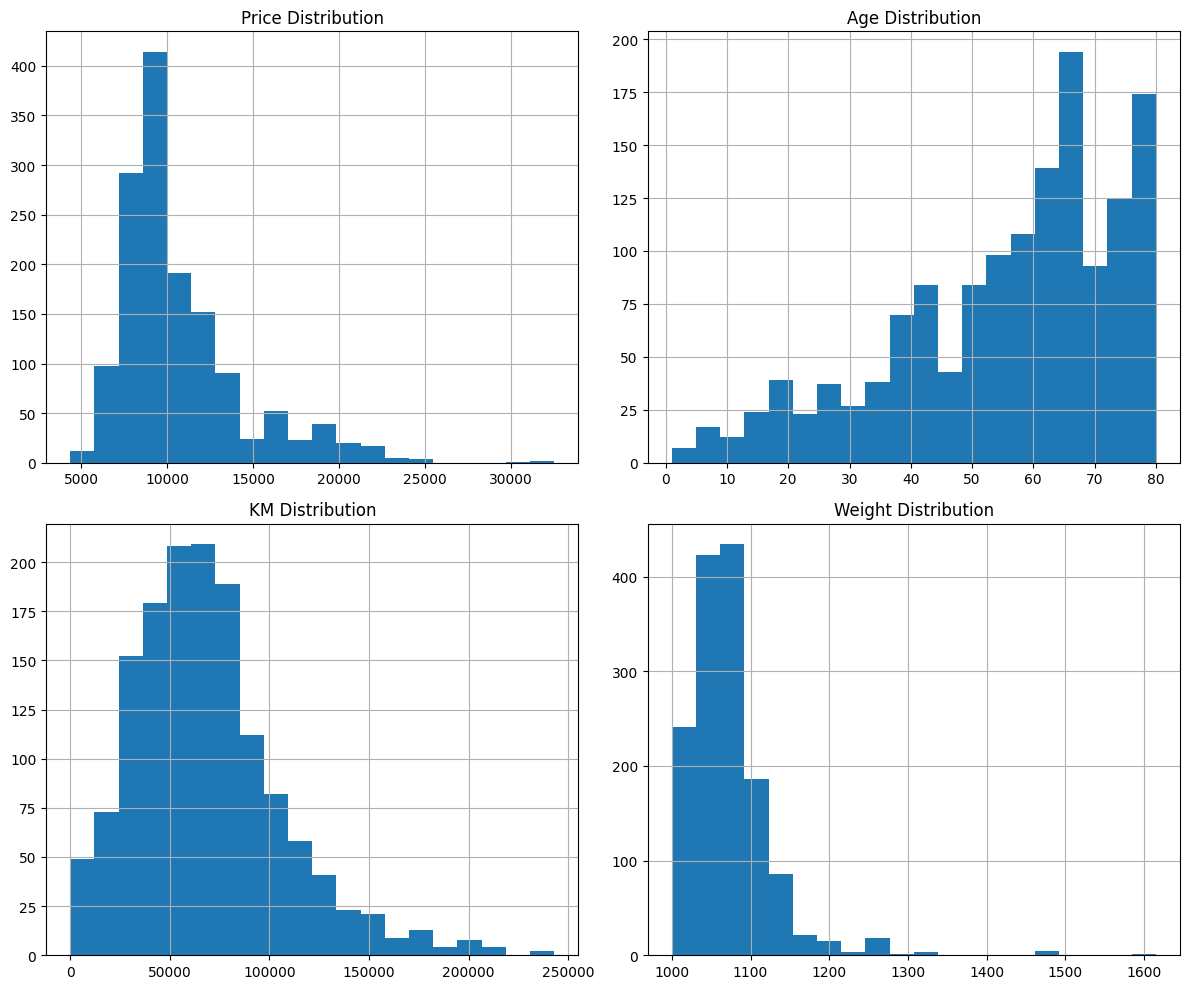

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
df['Price'].hist(ax=axes[0,0], bins=20)
axes[0,0].set_title('Price Distribution')
df['Age_08_04'].hist(ax=axes[0,1], bins=20)
axes[0,1].set_title('Age Distribution')
df['KM'].hist(ax=axes[1,0], bins=20)
axes[1,0].set_title('KM Distribution')
df['Weight'].hist(ax=axes[1,1], bins=20)
axes[1,1].set_title('Weight Distribution')
plt.tight_layout()
plt.show()

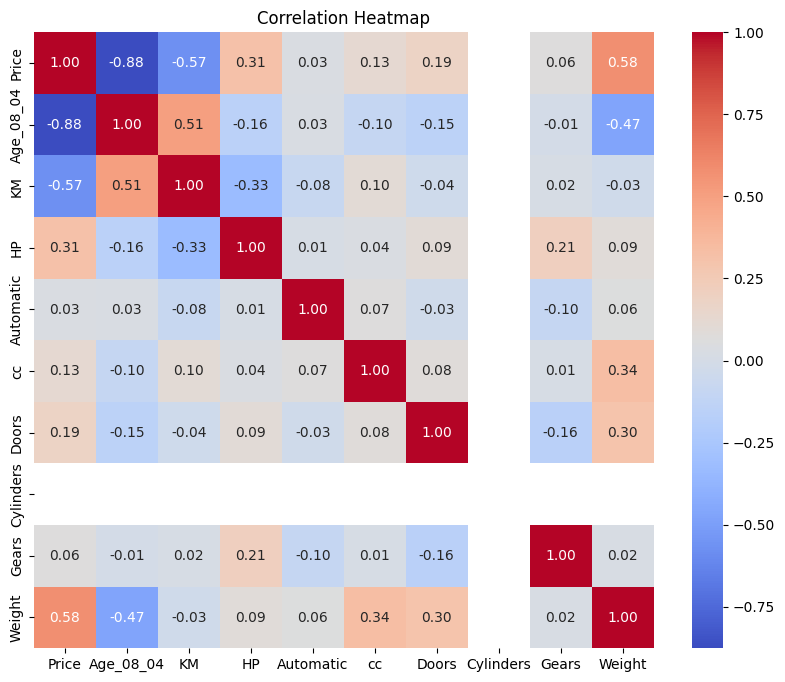

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns='Fuel_Type').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [8]:
df = df.drop(columns='Cylinders')
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True, dtype=int)
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,5,1165,1,0
1,13750,23,72937,90,0,2000,3,5,1165,1,0
2,13950,24,41711,90,0,2000,3,5,1165,1,0
3,14950,26,48000,90,0,2000,3,5,1165,1,0
4,13750,30,38500,90,0,2000,3,5,1170,1,0


In [9]:
x = df.drop(columns='Price')
y = df['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [11]:
def adj_r2(r, n, p):
    return 1 - (1 - r) * (n - 1) / (n - p - 1)

In [12]:
lr1 = LinearRegression()
lr1.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-2267.29, -611.65, 208.35,..., 1316.82, -21.72, 458.05]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.075e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[58.74,47.18,37.11,...,18.86,12.89, 8.28]"


In [13]:
print("Intercept:", lr1.intercept_)
coef_df = pd.DataFrame({'Feature': x.columns, 'Coefficient': lr1.coef_})
print(coef_df)

Intercept: 10754.395470383277
            Feature  Coefficient
0         Age_08_04 -2267.294783
1                KM  -611.654412
2                HP   208.349858
3         Automatic    34.397130
4                cc   -14.161917
5             Doors   -57.467804
6             Gears   109.340417
7            Weight  1316.818311
8  Fuel_Type_Diesel   -21.722173
9  Fuel_Type_Petrol   458.047731


In [14]:
y_pred1 = lr1.predict(x_test_scaled)
r2_1 = r2_score(y_test, y_pred1)
adj_r2_1 = adj_r2(r2_1, len(y_test), x_train.shape[1])
mae_1 = mean_absolute_error(y_test, y_pred1)
mse_1 = mean_squared_error(y_test, y_pred1)
rmse_1 = np.sqrt(mse_1)

In [15]:
y_train_log = np.log(y_train)
lr2 = LinearRegression()
lr2.fit(x_train_scaled, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-0.19,-0.06, 0.02,..., 0.06, 0.01, 0.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.236
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[58.74,47.18,37.11,...,18.86,12.89, 8.28]"


In [16]:
y_pred2_log = lr2.predict(x_test_scaled)
y_pred2 = np.exp(y_pred2_log)
r2_2 = r2_score(y_test, y_pred2)
adj_r2_2 = adj_r2(r2_2, len(y_test), x_train.shape[1])
mae_2 = mean_absolute_error(y_test, y_pred2)
mse_2 = mean_squared_error(y_test, y_pred2)
rmse_2 = np.sqrt(mse_2)

In [17]:
x_train_sm = sm.add_constant(x_train)
sm_model = sm.OLS(y_train, x_train_sm).fit()
infl = sm_model.get_influence()
cooks = infl.cooks_distance[0]
n_samples = len(y_train)
threshold = 4.0 / n_samples
outliers = np.where(cooks > threshold)[0]
print("Outliers detected:", len(outliers))

Outliers detected: 52


In [18]:
x_train_clean = x_train.drop(x_train.index[outliers])
y_train_clean = y_train.drop(y_train.index[outliers])

In [19]:
sc3 = StandardScaler()
x_train_clean_scaled = sc3.fit_transform(x_train_clean)
x_test_clean_scaled = sc3.transform(x_test)
lr3 = LinearRegression()
lr3.fit(x_train_clean_scaled, y_train_clean)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-2036.6 , -560.6 , 23.95,..., 1409.63, -104.22, 455.08]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.055e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[62.64,45.42,36.72,...,12.56, 9.26, 4.67]"


In [20]:
y_pred3 = lr3.predict(x_test_clean_scaled)
r2_3 = r2_score(y_test, y_pred3)
adj_r2_3 = adj_r2(r2_3, len(y_test), x_train_clean.shape[1])
mae_3 = mean_absolute_error(y_test, y_pred3)
mse_3 = mean_squared_error(y_test, y_pred3)
rmse_3 = np.sqrt(mse_3)

In [21]:
metrics_df = pd.DataFrame({
    'Model': ['Base MLR', 'Log-Target MLR', 'Outlier-Removed MLR'],
    'R2': [r2_1, r2_2, r2_3],
    'Adj_R2': [adj_r2_1, adj_r2_2, adj_r2_3],
    'MAE': [mae_1, mae_2, mae_3],
    'MSE': [mse_1, mse_2, mse_3],
    'RMSE': [rmse_1, rmse_2, rmse_3]
})
print(metrics_df)

                 Model        R2    Adj_R2         MAE           MSE  \
0             Base MLR  0.834889  0.828928  990.887274  2.203044e+06   
1       Log-Target MLR  0.881448  0.877169  862.997383  1.581808e+06   
2  Outlier-Removed MLR  0.806593  0.799610  975.431078  2.580593e+06   

          RMSE  
0  1484.265415  
1  1257.699493  
2  1606.422537  


In [22]:
lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(x_train_scaled, y_train)
y_pred_l = lasso.predict(x_test_scaled)
r2_l = r2_score(y_test, y_pred_l)
mae_l = mean_absolute_error(y_test, y_pred_l)
rmse_l = np.sqrt(mean_squared_error(y_test, y_pred_l))

In [23]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(x_train_scaled, y_train)
y_pred_r = ridge.predict(x_test_scaled)
r2_r = r2_score(y_test, y_pred_r)
mae_r = mean_absolute_error(y_test, y_pred_r)
rmse_r = np.sqrt(mean_squared_error(y_test, y_pred_r))

In [24]:
reg_metrics = pd.DataFrame({
    'Model': ['Lasso', 'Ridge'],
    'R2': [r2_l, r2_r],
    'MAE': [mae_l, mae_r],
    'RMSE': [rmse_l, rmse_r]
})
print(reg_metrics)

   Model        R2         MAE         RMSE
0  Lasso  0.835118  991.017466  1483.235687
1  Ridge  0.835046  990.859177  1483.557506


### 1. What is Normalization & Standardization and how is it helpful?
Normalization and standardization are two feature scaling techniques used to bring numerical variables onto a similar scale. Normalization scales the data to a fixed range, usually between 0 and 1, by subtracting the minimum value and dividing by the range, which is helpful when features have different bounds and we want to preserve the zero values. Standardization, on the other hand, centers the data around a mean of 0 and a standard deviation of 1, which is helpful for algorithms like linear regression that assume normally distributed variables and are sensitive to the magnitude of coefficients, ensuring that no single feature dominates the model simply because of its scale.

### 2. What techniques can be used to address multicollinearity in multiple linear regression?
Multicollinearity occurs when independent variables in a regression model are highly correlated with each other, making it difficult to estimate their individual effects. To address this, we can calculate the Variance Inflation Factor (VIF) for each variable and drop the ones with high VIF values, typically above 5 or 10. Other effective techniques include using regularization methods like Ridge or Lasso regression, which penalize large coefficients, combining highly correlated features into a single index, or performing Principal Component Analysis (PCA) to project the collinear features onto a smaller set of uncorrelated components.